In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, confusion_matrix, roc_curve

# Load the dataset

In [3]:
df = pd.read_csv('Pandas-Demo/data/data.csv')

# Pandas Interview Tasks

# Task 1: Calculate revenue growth rate for each user

In [4]:
df['revenue_growth_rate'] = df.groupby('user_id')['revenue'].transform(lambda x: 
                                                                       round((x - x.shift(1)) / x.shift(1) * 100, 2)).fillna(0).map(lambda x: 
                                                                                                                                    f"{x}%" if x < 0 else f"+{x}%")

# Task 2: Find users with three consecutive revenue increases followed by a decline

In [5]:
df['revenue_diff'] = df.groupby('user_id')['revenue'].diff()
def get_trend(x):
    if pd.isna(x) or x == 0:
        return 0
    return 1 if x > 0 else -1
df['trend'] = df['revenue_diff'].apply(get_trend)
df['t_0'] = df['trend']
df['t_1'] = df.groupby('user_id')['trend'].shift(-1)
df['t_2'] = df.groupby('user_id')['trend'].shift(-2)
df['t_3'] = df.groupby('user_id')['trend'].shift(-3)

df[(df['t_0'] == 1) & 
    (df['t_1'] == 1) & 
    (df['t_2'] == 1) & 
    (df['t_3'] == -1)]

,employee_id,user_id,country,date,revenue,salary,department,feature_1,feature_2,feature_3,target,revenue_growth_rate,revenue_diff,trend,t_0,t_1,t_2,t_3
8,9,1008,USA,2026-01-09,513.0,59830.0,Finance,-0.418509,-2.704901,5.181507,0,+165.8%,320.0,1,1,1.0,1.0,-1.0
22,23,1010,USA,2026-01-23,538.0,137888.0,Finance,-2.216761,-0.619486,4.128753,0,+210.98%,365.0,1,1,1.0,1.0,-1.0


# Task 3: Calculate cumulative average revenue by country

In [6]:
df['avg_revenue'] = df.groupby('country')['revenue'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())

# Task 4: Find the day with the largest revenue increase

In [7]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by = 'date')
daily_df = df.groupby('date')['revenue'].sum().reset_index()
daily_df['revenue_growth'] = daily_df['revenue'] - daily_df['revenue'].shift()
ind = daily_df['revenue_growth'].idxmax()
daily_df.loc[ind, 'date']

Timestamp('2026-02-15 00:00:00')

# Task 5: Calculate days since the previous purchase

In [8]:
df = df.sort_values(by = ['user_id', 'date'])
df['day'] = df['date'].dt.day
df['days_since_previous_purchase'] = df.groupby('user_id')['day'].transform(lambda x: x - x.shift()).fillna('first_purchase')

# Task 6: Find users in the top 5% of revenue within each country

In [9]:
a = df.groupby(['user_id', 'country'])['revenue'].last().reset_index()
res = a.loc[a['revenue'] > a.groupby('country')['revenue'].transform(lambda x: x.quantile(0.95))] 
res

,user_id,country,revenue
2,1001,UK,850.0
17,1005,Canada,760.0
19,1005,Germany,946.0
21,1006,France,978.0
43,1010,USA,965.0


# Numpy Interview Tasks

# Create a NumPy feature matrix

In [10]:
feature_cols = ['feature_1', 'feature_2', 'feature_3']
a = df[feature_cols].values

# Task 1: Find the top 3 rows with the largest row sums

In [11]:
b = a.sum(axis = 1)
res_1 = b[np.argpartition(b, -3)[-3:]]
res_1

array([10.26734221, 10.31839415, 10.34932949])

# Task 2: Compute the correlation of every column with the last column

In [12]:
matrix_corr = np.corrcoef(a.T)
res_2 = matrix_corr[-1,:]
res_2

array([0.0168487, 0.0365959, 1.       ])

# Task 3: Find rows where at least 80% of values are above their column means

In [13]:
res_3 = np.mean(a > a.mean(axis = 0, keepdims = True), axis = 1)
a[res_3 >= 0.8]

array([[-0.07873168,  2.07431693,  5.90186344],
       [ 1.68801703,  3.05420252,  5.5761746 ],
       [ 0.73317336,  2.99977735,  5.46451661],
       [ 1.67529325,  2.68417701,  5.90787195],
       [ 0.05557216,  1.18748435,  5.81585162],
       [ 0.4455069 ,  0.720338  ,  5.21586065],
       [ 0.38279947,  2.87236694,  5.22333616],
       [ 1.35881663,  0.15209608,  5.53191689],
       [ 0.32451832,  0.8274256 ,  5.17396633],
       [ 0.88620197,  3.22115693,  6.2419706 ],
       [ 0.28988281,  1.73214103,  5.98749301],
       [ 0.79059399,  1.61511126,  7.1728423 ],
       [ 0.26763601,  0.98881857,  5.59540114],
       [ 1.86077805,  1.29146558,  5.47682809],
       [ 0.04560784,  1.23221331,  5.51612473],
       [ 0.06023292,  2.42563015,  5.56675593],
       [ 0.49214103,  0.51733382,  5.07526595],
       [ 0.76157184,  1.12206613,  6.50502511],
       [ 0.05741295,  0.08740534,  5.18351182],
       [ 0.63285244,  1.84830477,  6.56281357],
       [ 0.84357402,  0.10168514,  5.742

# Task 4: Standardize every feature using Z-score normalization

In [14]:
res_4 = (a - a.mean(axis = 0)) / a.std(axis = 0)
res_4

array([[ 9.63763608e-03,  1.03096968e+00,  8.43527570e-01],
       [ 1.60921607e+00,  1.50380026e+00,  5.11849394e-01],
       [ 3.06644030e-01, -5.19405270e-01, -1.16988998e-01],
       [ 1.38805913e+00, -1.72572177e+00, -6.68215351e-01],
       [ 7.44719989e-01,  1.47753813e+00,  3.98138037e-01],
       [-2.14558405e+00,  1.64532523e+00, -1.33959857e+00],
       [-1.78332620e-01,  3.70668176e-01,  6.34235938e-01],
       [ 5.51874937e-02, -5.93690192e-01, -3.32491343e-01],
       [ 1.28188023e+00, -1.63984461e+00,  4.04778168e-01],
       [-2.14322987e+00, -1.27350930e+00,  2.04788934e+00],
       [-1.89156169e-01, -7.21833293e-01,  1.01216551e+00],
       [-1.13438309e+00,  2.84571959e-02, -2.19228329e+00],
       [ 1.59769621e+00,  1.32524944e+00,  8.49646575e-01],
       [ 1.31233608e-01,  6.03040583e-01,  7.55934017e-01],
       [ 1.21073799e-01, -8.08208977e-01, -1.00134290e+00],
       [ 4.84272611e-01,  3.77625413e-01,  1.44909358e-01],
       [ 1.41929917e+00,  1.19985550e+00

# Task 5: Compute cosine similarity between all rows

In [15]:
dot_product = a @ a.T
norms = np.linalg.norm(a, axis = 1, keepdims = True)
norms_matrix = norms @ norms.T
res_5 = dot_product / norms_matrix
res_5

array([[1.        , 0.95038088, 0.8435898 , ..., 0.75570171, 0.86039542,
        0.63692953],
       [0.95038088, 1.        , 0.7339693 , ..., 0.5400547 , 0.76032829,
        0.48096746],
       [0.8435898 , 0.7339693 , 1.        , ..., 0.91820492, 0.99917744,
        0.94792496],
       ...,
       [0.75570171, 0.5400547 , 0.91820492, ..., 1.        , 0.90678158,
        0.91971167],
       [0.86039542, 0.76032829, 0.99917744, ..., 0.90678158, 1.        ,
        0.93490452],
       [0.63692953, 0.48096746, 0.94792496, ..., 0.91971167, 0.93490452,
        1.        ]], shape=(100, 100))

# ML Interview Tasks

# Split features and target

In [16]:
X = df.drop(columns = ['target'])
y = df['target']

# Split the dataset into training and test sets

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

# Define numerical and categorical features

In [18]:
num_cols = [
    'revenue', 
    'salary', 
    'avg_revenue',
    'feature_1', 
    'feature_2', 
    'feature_3'
]

cat_cols = [
    'country', 
    'department'
]

# Apply preprocessing to numerical and categorical features

In [19]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown = 'ignore'), cat_cols)
])

# Define preprocessing pipelines

In [20]:
pipe_1 = Pipeline([ ('preprocessor', preprocessor), 
                  ('poly', PolynomialFeatures(degree = 2, include_bias = False)), 
                  ('model', LogisticRegression()) ])

pipe_2 = Pipeline([ ('preprocessor', preprocessor), 
                   ('model', RandomForestClassifier(random_state = 42)) ]) 

pipe_3 = Pipeline([ ('preprocessor', preprocessor), 
                   ('model', XGBClassifier()) ]) 
pipe_1.fit(X_train, y_train) # Train Logistic Regression model
pipe_2.fit(X_train, y_train) # Train Random Forest model
pipe_3.fit(X_train, y_train) # Train XGBClassifier model
preds_1 = pipe_1.predict(X_test)
preds_2 = pipe_2.predict(X_test)
preds_3 = pipe_3.predict(X_test)

# Compare models using cross-validation

In [80]:
scores_lr = cross_val_score(pipe_1, X, y, cv = 5, n_jobs = -1, scoring = 'accuracy') 
scores_rf = cross_val_score(pipe_2, X, y, cv = 5, n_jobs = -1, scoring = 'accuracy') 
scores_xgb = cross_val_score(pipe_3, X, y, cv = 5, n_jobs = -1, scoring = 'accuracy') 
scores_lr_2 = cross_val_score(pipe_1, X, y, cv = 5, n_jobs = -1, scoring = 'roc_auc') 
scores_rf_2 = cross_val_score(pipe_2, X, y, cv = 5, n_jobs = -1, scoring = 'roc_auc') 
scores_xgb_2 = cross_val_score(pipe_3, X, y, cv = 5, n_jobs = -1, scoring = 'roc_auc')

# Optimize the decision threshold

In [66]:
y_probs = pipe_1.predict_proba(X_test)[:,1] 
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_probs) 
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10) 
best_idx_pr = np.argmax(f1_scores) 
best_threshold_pr = thresholds_pr[best_idx_pr] 
best_threshold_pr 

np.float64(0.06666570767820923)

# Create feature-importance dataframe

In [36]:
features = pipe_2.named_steps['preprocessor'].get_feature_names_out()
importances = pipe_2.named_steps['model'].feature_importances_
f_a_df = pd.DataFrame({'features' : features, 'importances' : importances}).sort_values(by = 'importances', ascending = False)
f_a_df

,features,importances
1,num__salary,0.204250
4,num__feature_2,0.140795
0,num__revenue,0.127759
3,num__feature_1,0.118577
5,num__feature_3,0.114176
2,num__avg_revenue,0.113758
10,cat__country_USA,0.046726
8,cat__country_Germany,0.024267
11,cat__department_Finance,0.022567
13,cat__department_IT,0.020874


# Data Visualization Interview Tasks

# Task 1: Revenue Distribution by Country and Quarter

<Axes: xlabel='country', ylabel='revenue'>

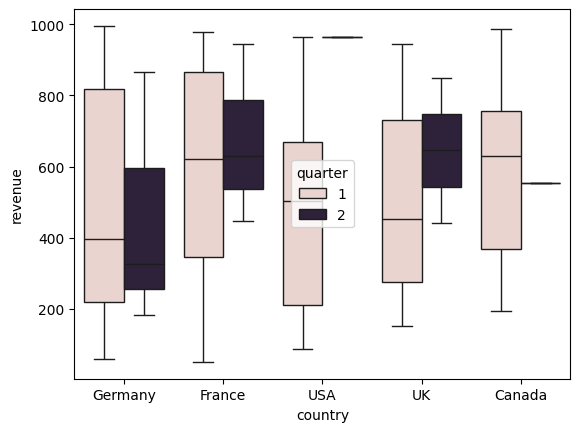

In [75]:
df['date'] = pd.to_datetime(df['date']) 
df['quarter'] = df['date'].dt.quarter 
sns.boxplot(data = df, x = 'country', y = 'revenue', hue = 'quarter')

# Task 2: Actual vs predicted values

<Axes: >

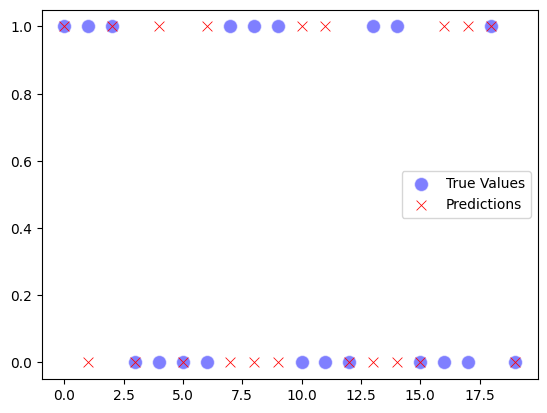

In [76]:
sns.scatterplot(x = range(len(y_test)), y = y_test.values, c = 'blue', alpha = 0.5, label = 'True Values', s = 100, marker = 'o') 
sns.scatterplot(x = range(len(y_test)), y = preds_1, c = 'red', label = 'Predictions', s = 50, marker = 'x')

# Task 3: ROC curve

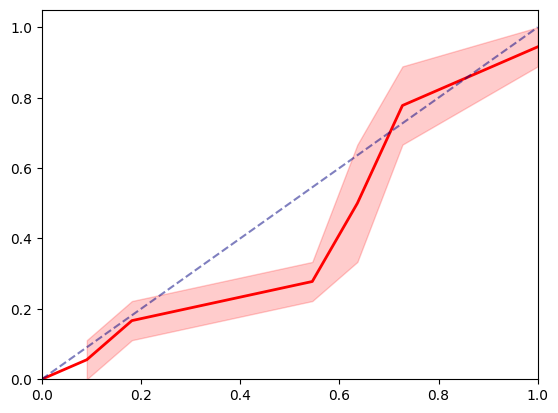

In [82]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs) 
sns.lineplot(x = fpr, y = tpr, c = 'red', lw = 2) 
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", alpha = 0.5) 
plt.xlim([0.0, 1.0]) 
plt.ylim([0.0, 1.05]) 
plt.show()

# Task 4: Feature Importance Analysis

<Axes: >

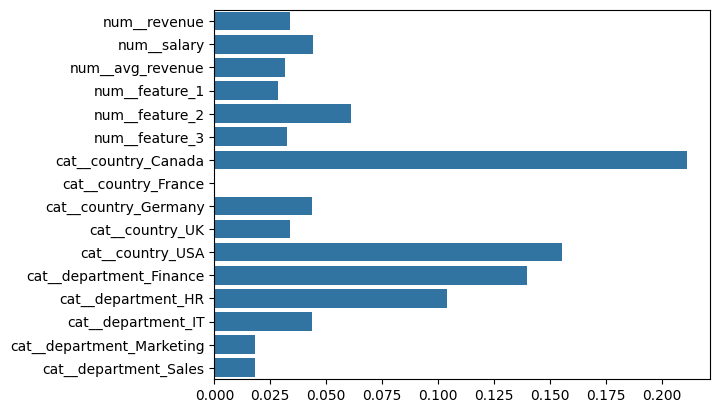

In [84]:
features = pipe_3.named_steps['preprocessor'].get_feature_names_out() 
importances = pipe_3.named_steps['model'].feature_importances_ 
sns.barplot(y = features, x= importances) 

# Task 5: Dashboard(2x2):
# 1. Salary Distribution (Histplot)
# 2. Correlation Matrix (Heatmap)
# 3. Departmental Breakdown (Boxplot)
# 4. Top 15 Earners (Barplot)

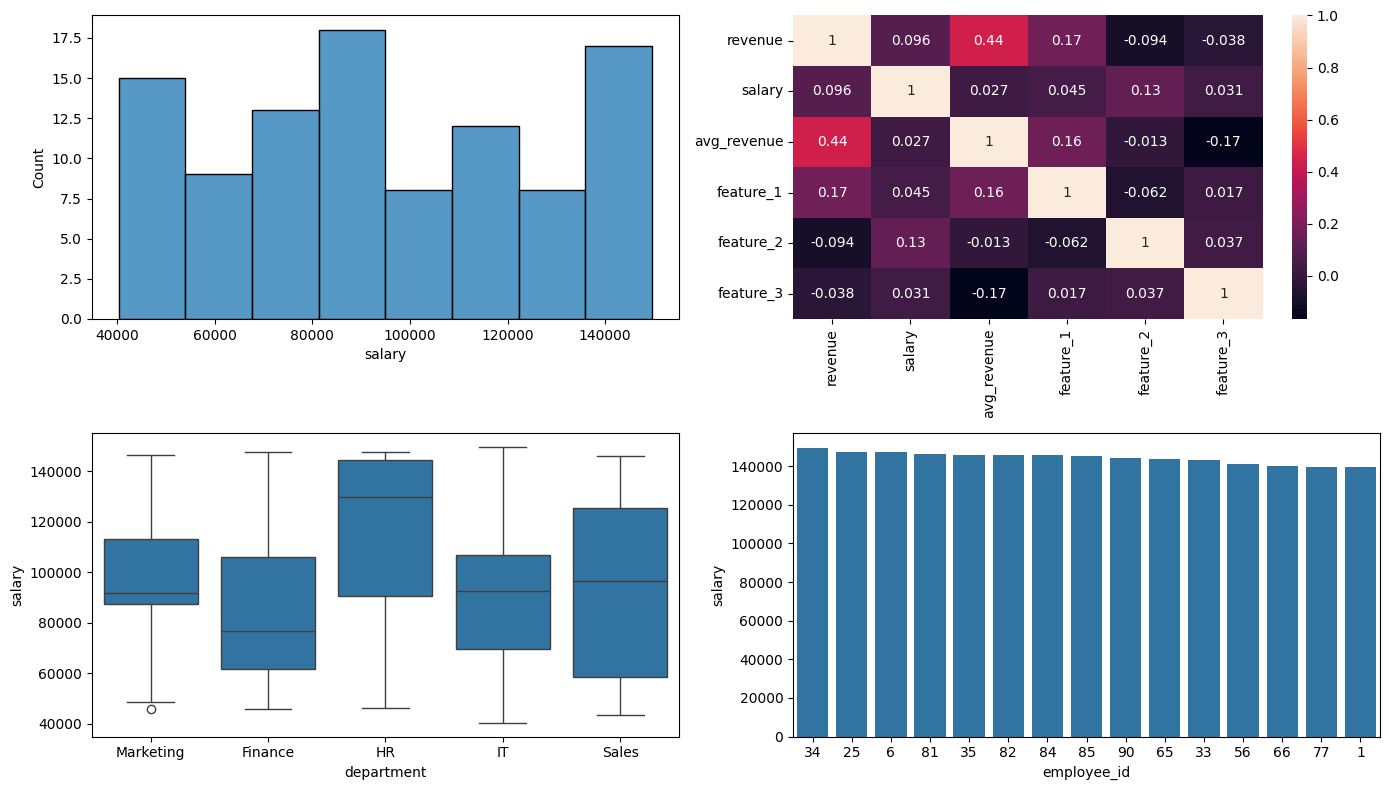

In [43]:
fig, ax = plt.subplots(2, 2, figsize = (14, 8)) 
corr = df[num_cols].corr() 
sns.histplot(data = df, x = 'salary', ax = ax[0,0]) 
sns.heatmap(corr, annot = True, ax = ax[0,1]) 
sns.boxplot(data = df, x = 'department', y = 'salary', ax = ax[1,0]) 
top_earners = df.sort_values(by='salary', ascending=False).head(15)
sns.barplot(data = top_earners, y = 'salary', x = 'employee_id', ax = ax[1,1], order = top_earners['employee_id']) 
plt.tight_layout()

In [94]:
df

,employee_id,user_id,country,date,revenue,salary,department,feature_1,feature_2,feature_3,...,revenue_diff,trend,t_0,t_1,t_2,t_3,avg_revenue,day,days_since_previous_purchase,quarter
21,22,1001,Germany,2026-01-22,869.0,94045.0,Marketing,-0.078732,2.074317,5.901863,...,NaN,0,0,-1.0,-1.0,-1.0,461.714286,22,first_purchase,1
25,26,1001,France,2026-01-26,689.0,45600.0,Marketing,1.688017,3.054203,5.576175,...,-180.0,-1,-1,-1.0,-1.0,1.0,662.600000,26,4.0,1
51,52,1001,USA,2026-02-21,209.0,106235.0,Finance,0.249315,-1.138652,4.958692,...,-480.0,-1,-1,-1.0,1.0,1.0,487.000000,21,-5.0,1
78,79,1001,USA,2026-03-20,202.0,106320.0,Marketing,1.443747,-3.638601,4.417419,...,-7.0,-1,-1,1.0,1.0,1.0,369.714286,20,-1.0,1
83,84,1001,France,2026-03-25,387.0,145647.0,HR,0.733173,2.999777,5.464517,...,185.0,1,1,1.0,1.0,NaN,526.428571,25,5.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,64,1010,UK,2026-03-05,722.0,106105.0,Marketing,-1.176127,0.232822,5.638624,...,269.0,1,1,-1.0,-1.0,-1.0,418.142857,5,4.0,1
65,66,1010,Germany,2026-03-07,677.0,140199.0,IT,-1.461757,3.437199,6.708996,...,-45.0,-1,-1,-1.0,-1.0,1.0,355.285714,7,2.0,1
75,76,1010,USA,2026-03-17,559.0,50729.0,Sales,-1.171977,-0.962677,3.055061,...,-118.0,-1,-1,-1.0,1.0,NaN,508.000000,17,10.0,1
93,94,1010,Germany,2026-04-04,326.0,48716.0,Marketing,0.389180,-1.057448,5.475494,...,-233.0,-1,-1,1.0,NaN,NaN,456.000000,4,-13.0,2
